#  UIDAI Aadhaar Intelligence Pipeline: Data Ingestion, Cleaning & Comprehensive EDA

**Project:** Aadhaar Multi-Shard Data Engineering & Societal Trend Analysis  
**Author / Team:** Aadhaar Analytics Team  
**Dataset Coverage:** ~5 Million transaction records across Enrolment, Demographic Updates, and Biometric Updates across 28 States & 8 Union Territories in India.

---

## Executive Objectives
1. **Multi-Shard Data Ingestion**: Load, inspect, and concatenate chunked CSV shards across 3 operational domains (Enrolments, Demographic Updates, Biometric Updates).
2. **Canonical State Normalization**: Resolve misspellings, legacy naming conventions, abbreviations, and merged Union Territories using standardized census mapping.
3. **Data Quality & Hygiene**: Impute missing values, validate dates, handle duplicate state-date entries, and compute cross-domain composite indices.
4. **Exploratory Data Analysis & Societal Trends**:
   - Macro temporal dynamics (daily/monthly volumes, 30-day moving averages).
   - Demographic distribution by age cohort (0-5, 5-17, 18+).
   - Geographic disparity (Maintenance states vs Growth states).
   - Seasonality and Day-of-Week load distributions.
   - Correlation dynamics between update channels and new registrations.
5. **Clean Data Export**: Generate preprocessed, ready-to-model datasets (`cleaned_aadhaar_data.csv`, `cleaned_aadhaar_summary_by_state.csv`, `cleaned_aadhaar_monthly_national.csv`).

## 1. Setup & Environment Initialization
We import standard data science and visualization libraries: `pandas`, `numpy`, `matplotlib`, `seaborn`, `plotly`, and utility libraries.

In [1]:
import os
import glob
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go

# Configuration
warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid' in plt.style.available else 'default')
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 11

print("✓ Environment initialized successfully.")

✓ Environment initialized successfully.


## 2. Defining State Population Benchmarks & Canonical Aliases
To analyze per-capita intensity and normalize naming inconsistencies across raw government CSVs, we define the official census population mapping and alias resolution dictionary.

In [2]:
STATE_POPULATION = {
    "Andaman & Nicobar":    397_000, "Andhra Pradesh": 49_577_103,
    "Arunachal Pradesh": 1_570_458, "Assam": 34_293_000, "Bihar": 121_243_000,
    "Chandigarh": 1_158_000, "Chhattisgarh": 28_724_000,
    "Dadra & Nagar Haveli and Daman & Diu": 615_000, "Delhi": 20_667_656,
    "Goa": 1_586_250, "Gujarat": 66_750_000, "Haryana": 28_204_000,
    "Himachal Pradesh": 7_503_000, "Jammu and Kashmir": 14_999_397,
    "Jharkhand": 36_480_000, "Karnataka": 66_165_000, "Kerala": 35_125_000,
    "Ladakh": 316_000, "Lakshadweep": 73_183, "Madhya Pradesh": 82_232_000,
    "Maharashtra": 123_144_000, "Manipur": 3_091_545, "Meghalaya": 3_366_710,
    "Mizoram": 1_239_244, "Nagaland": 2_157_059, "Odisha": 45_429_000,
    "Puducherry": 1_413_542, "Punjab": 30_141_373, "Rajasthan": 79_502_477,
    "Sikkim": 682_000, "Tamil Nadu": 77_841_000, "Telangana": 38_705_209,
    "Tripura": 4_169_794, "Uttar Pradesh": 231_502_578,
    "Uttarakhand": 11_250_858, "West Bengal": 100_896_618,
}

STATE_ALIASES = {
    "andaman and nicobar islands": "Andaman & Nicobar",
    "andaman & nicobar islands": "Andaman & Nicobar",
    "a & n islands": "Andaman & Nicobar",
    "andhra pradesh": "Andhra Pradesh",
    "arunachal pradesh": "Arunachal Pradesh",
    "assam": "Assam",
    "bihar": "Bihar",
    "chandigarh": "Chandigarh",
    "chhattisgarh": "Chhattisgarh",
    "chhatisgarh": "Chhattisgarh",
    "dadra and nagar haveli": "Dadra & Nagar Haveli and Daman & Diu",
    "daman and diu": "Dadra & Nagar Haveli and Daman & Diu",
    "dadra and nagar haveli and daman and diu": "Dadra & Nagar Haveli and Daman & Diu",
    "dadra & nagar haveli": "Dadra & Nagar Haveli and Daman & Diu",
    "daman & diu": "Dadra & Nagar Haveli and Daman & Diu",
    "the dadra and nagar haveli and daman and diu": "Dadra & Nagar Haveli and Daman & Diu",
    "delhi": "Delhi",
    "nct of delhi": "Delhi",
    "goa": "Goa",
    "gujarat": "Gujarat",
    "haryana": "Haryana",
    "himachal pradesh": "Himachal Pradesh",
    "jammu and kashmir": "Jammu and Kashmir",
    "jammu & kashmir": "Jammu and Kashmir",
    "jharkhand": "Jharkhand",
    "karnataka": "Karnataka",
    "kerala": "Kerala",
    "ladakh": "Ladakh",
    "lakshadweep": "Lakshadweep",
    "madhya pradesh": "Madhya Pradesh",
    "maharashtra": "Maharashtra",
    "manipur": "Manipur",
    "meghalaya": "Meghalaya",
    "mizoram": "Mizoram",
    "nagaland": "Nagaland",
    "odisha": "Odisha",
    "orissa": "Odisha",
    "puducherry": "Puducherry",
    "pondicherry": "Puducherry",
    "punjab": "Punjab",
    "rajasthan": "Rajasthan",
    "sikkim": "Sikkim",
    "tamil nadu": "Tamil Nadu",
    "telangana": "Telangana",
    "tripura": "Tripura",
    "uttar pradesh": "Uttar Pradesh",
    "uttarakhand": "Uttarakhand",
    "uttaranchal": "Uttarakhand",
    "west bengal": "West Bengal",
    "westbengal": "West Bengal",
    "west bangal": "West Bengal",
    "west  bengal": "West Bengal",
}

def clean_state_name(raw_name):
    if pd.isna(raw_name):
        return "Unknown"
    cleaned = str(raw_name).strip().lower()
    cleaned = " ".join(cleaned.split())
    if cleaned in STATE_ALIASES:
        return STATE_ALIASES[cleaned]
    for official in STATE_POPULATION.keys():
        if cleaned == official.lower():
            return official
    return str(raw_name).strip().title()

print(f"Loaded {len(STATE_POPULATION)} canonical states/UTs and {len(STATE_ALIASES)} alias mappings.")

Loaded 36 canonical states/UTs and 52 alias mappings.


## 3. Raw Data Ingestion Across All Multi-Shard CSVs
We locate and load all chunked CSV files across the three data folders:
1. `api_data_aadhar_enrolment`
2. `api_data_aadhar_demographic`
3. `api_data_aadhar_biometric`

In [3]:
def load_and_aggregate_domain(folder_name, value_cols, domain_prefix=''):
    all_files = glob.glob(f"{folder_name}/**/*.csv", recursive=True)
    if not all_files:
        all_files = glob.glob(f"../{folder_name}/**/*.csv", recursive=True)
    
    print(f"[{domain_prefix.upper() or folder_name}] Found {len(all_files)} CSV files to process.")
    
    dfs = []
    for f in all_files:
        try:
            temp_df = pd.read_csv(f, dtype={'state': str, 'district': str, 'pincode': str})
            dfs.append(temp_df)
        except Exception as e:
            print(f"Error loading {f}: {e}")
            
    if not dfs:
        print(f"Warning: No data loaded for {folder_name}")
        return pd.DataFrame()
        
    df = pd.concat(dfs, ignore_index=True)
    print(f"  → Total raw records loaded: {len(df):,}")
    
    # Clean date
    df['date'] = pd.to_datetime(df['date'], format='%d-%m-%Y', errors='coerce')
    df = df.dropna(subset=['date'])
    
    # Normalize state name
    df['state'] = df['state'].apply(clean_state_name)
    df = df[df['state'].isin(STATE_POPULATION.keys())]
    
    # Ensure numeric value columns
    for col in value_cols:
        if col in df.columns:
            df[col] = pd.to_numeric(df[col], errors='coerce').fillna(0)
        else:
            df[col] = 0
            
    # Daily state level aggregation
    agg_df = df.groupby(['date', 'state'])[value_cols].sum().reset_index()
    return agg_df

# Ingestion
df_enrol = load_and_aggregate_domain('api_data_aadhar_enrolment', ['age_0_5', 'age_5_17', 'age_18_greater'], 'enrol')
df_demo = load_and_aggregate_domain('api_data_aadhar_demographic', ['demo_age_5_17', 'demo_age_18_greater'], 'demo')
df_bio = load_and_aggregate_domain('api_data_aadhar_biometric', ['bio_age_5_17', 'bio_age_18_greater'], 'bio')

print("\nAggregation Complete:")
print(f"Enrolment Aggregated Shape: {df_enrol.shape}")
print(f"Demographic Aggregated Shape: {df_demo.shape}")
print(f"Biometric Aggregated Shape:   {df_bio.shape}")

[ENROL] Found 3 CSV files to process.


  → Total raw records loaded: 1,006,029


[DEMO] Found 5 CSV files to process.


  → Total raw records loaded: 2,071,700


[BIO] Found 4 CSV files to process.


  → Total raw records loaded: 1,861,108



Aggregation Complete:
Enrolment Aggregated Shape: (2918, 5)
Demographic Aggregated Shape: (3359, 4)
Biometric Aggregated Shape:   (3155, 4)


## 4. Multi-Shard Outer Join & Derived Composite Features
We perform an outer merge of all three domains across `date` and `state`, compute aggregate metrics, calculate workload ratios, and link state populations.

In [4]:
# Merging all 3 domains
merged = pd.merge(df_enrol, df_demo, on=['date', 'state'], how='outer')
merged = pd.merge(merged, df_bio, on=['date', 'state'], how='outer')

# Fill NaN counts with 0
numeric_cols = [
    'age_0_5', 'age_5_17', 'age_18_greater',
    'demo_age_5_17', 'demo_age_18_greater',
    'bio_age_5_17', 'bio_age_18_greater'
]
merged[numeric_cols] = merged[numeric_cols].fillna(0)

# Sort strictly chronologically by date and state
merged = merged.sort_values(['date', 'state']).reset_index(drop=True)

# 1. Total Enrolments
merged['total_enrolments'] = merged['age_0_5'] + merged['age_5_17'] + merged['age_18_greater']

# 2. Demographic Updates
merged['demo_total'] = merged['demo_age_5_17'] + merged['demo_age_18_greater']

# 3. Biometric Updates
merged['bio_total'] = merged['bio_age_5_17'] + merged['bio_age_18_greater']

# 4. Total Updates Combined
merged['total_updates'] = merged['demo_total'] + merged['bio_total']

# 5. Total System Load (Operational traffic at Aadhaar centers & servers)
merged['total_system_load'] = merged['total_enrolments'] + merged['total_updates']

# 6. Domain Ratios
merged['update_to_enrolment_ratio'] = merged['total_updates'] / (merged['total_enrolments'] + 1.0)
merged['bio_to_demo_ratio'] = merged['bio_total'] / (merged['demo_total'] + 1.0)

# 7. Add population & per-capita rate
merged['population'] = merged['state'].map(STATE_POPULATION)
merged['load_per_million_pop'] = (merged['total_system_load'] / merged['population']) * 1_000_000

display(merged.head(10))
print(f"Final merged master dataset contains {len(merged):,} daily state records.")

,date,state,age_0_5,age_5_17,age_18_greater,demo_age_5_17,demo_age_18_greater,bio_age_5_17,bio_age_18_greater,total_enrolments,demo_total,bio_total,total_updates,total_system_load,update_to_enrolment_ratio,bio_to_demo_ratio,population,load_per_million_pop
0,2025-03-01,Andaman & Nicobar,0.0,0.0,0.0,126.0,0.0,1612.0,0.0,0.0,126.0,1612.0,1738.0,1738.0,1738.0,12.692913,397000,4377.833753
1,2025-03-01,Andhra Pradesh,0.0,0.0,0.0,48600.0,0.0,243777.0,0.0,0.0,48600.0,243777.0,292377.0,292377.0,292377.0,5.015884,49577103,5897.420025
2,2025-03-01,Arunachal Pradesh,0.0,0.0,0.0,852.0,0.0,2953.0,0.0,0.0,852.0,2953.0,3805.0,3805.0,3805.0,3.461899,1570458,2422.860083
3,2025-03-01,Assam,0.0,0.0,0.0,16692.0,0.0,59101.0,0.0,0.0,16692.0,59101.0,75793.0,75793.0,75793.0,3.540466,34293000,2210.159508
4,2025-03-01,Bihar,0.0,0.0,0.0,95221.0,0.0,324179.0,0.0,0.0,95221.0,324179.0,419400.0,419400.0,419400.0,3.404455,121243000,3459.168777
5,2025-03-01,Chandigarh,0.0,0.0,0.0,1296.0,0.0,3053.0,0.0,0.0,1296.0,3053.0,4349.0,4349.0,4349.0,2.353894,1158000,3755.613126
6,2025-03-01,Chhattisgarh,0.0,0.0,0.0,18699.0,0.0,37255.0,0.0,0.0,18699.0,37255.0,55954.0,55954.0,55954.0,1.992246,28724000,1947.987745
7,2025-03-01,Dadra & Nagar Haveli and Daman & Diu,0.0,0.0,0.0,136.0,0.0,1715.0,0.0,0.0,136.0,1715.0,1851.0,1851.0,1851.0,12.518248,615000,3009.756098
8,2025-03-01,Delhi,0.0,0.0,0.0,24234.0,0.0,62172.0,0.0,0.0,24234.0,62172.0,86406.0,86406.0,86406.0,2.565381,20667656,4180.735348
9,2025-03-01,Goa,0.0,0.0,0.0,1223.0,0.0,4037.0,0.0,0.0,1223.0,4037.0,5260.0,5260.0,5260.0,3.298203,1586250,3315.996848


Final merged master dataset contains 3,831 daily state records.


## 5. Exploratory Data Analysis & Macro Trends

### 5.1 Macro Temporal Dynamics: National Daily Volume & 30-Day Moving Average
We aggregate the daily national totals to observe macroscopic traffic trends, peak operational periods, and long-term moving averages.

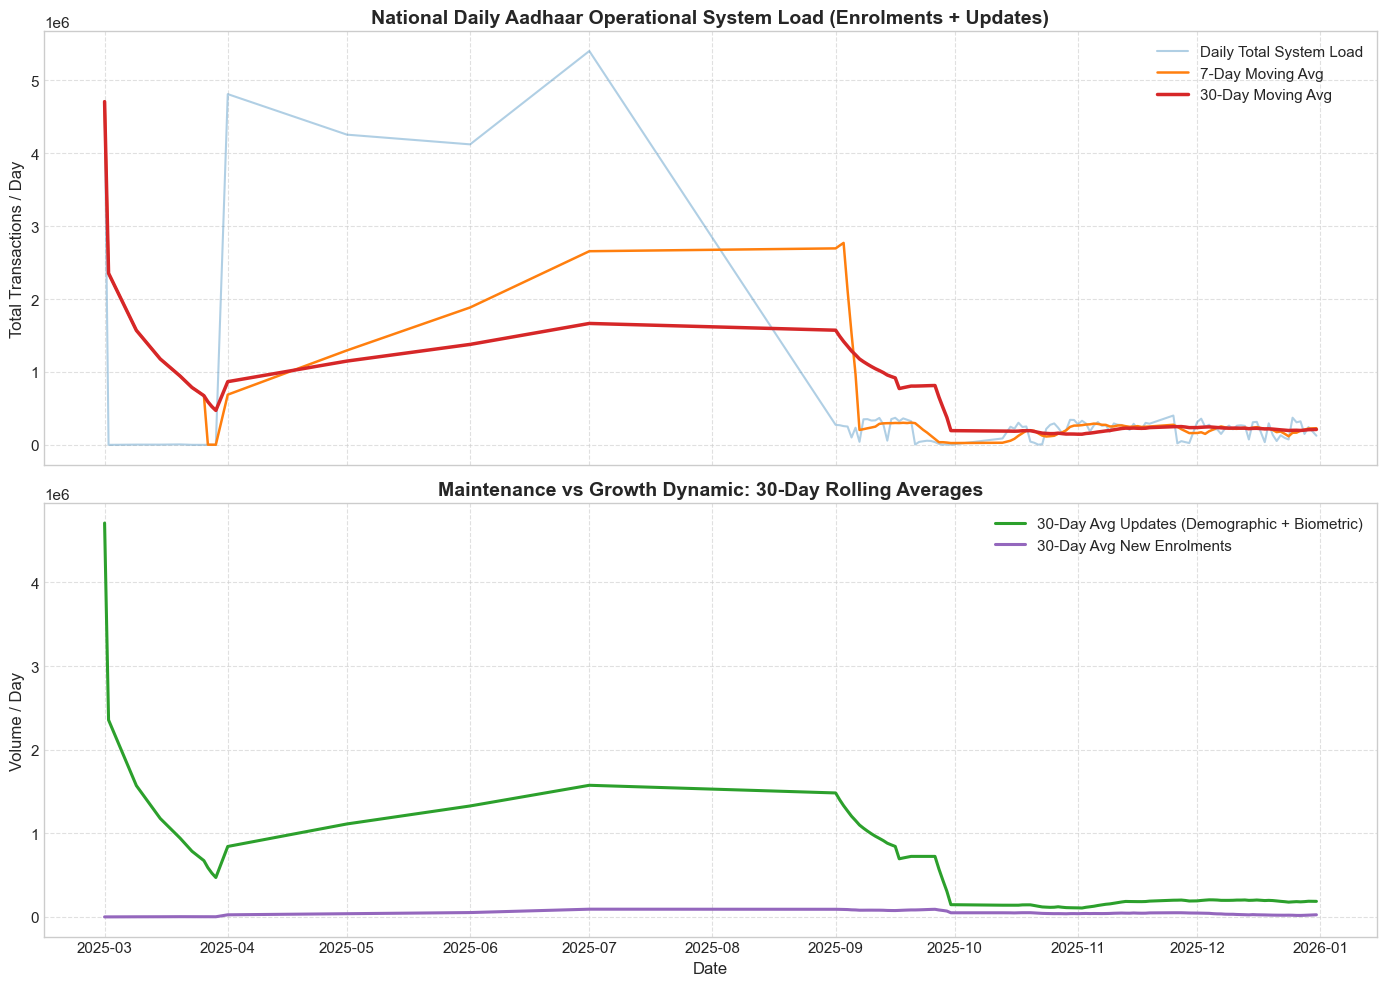

In [5]:
# National Daily Aggregation
national_daily = merged.groupby('date')[['total_enrolments', 'demo_total', 'bio_total', 'total_updates', 'total_system_load']].sum().reset_index()

# 7-day and 30-day Rolling Averages
national_daily['load_7d_ma'] = national_daily['total_system_load'].rolling(window=7, min_periods=1).mean()
national_daily['load_30d_ma'] = national_daily['total_system_load'].rolling(window=30, min_periods=1).mean()
national_daily['enrol_30d_ma'] = national_daily['total_enrolments'].rolling(window=30, min_periods=1).mean()
national_daily['updates_30d_ma'] = national_daily['total_updates'].rolling(window=30, min_periods=1).mean()

fig, ax = plt.subplots(2, 1, figsize=(14, 10), sharex=True)

# Plot 1: Total System Load vs Moving Averages
ax[0].plot(national_daily['date'], national_daily['total_system_load'], color='#1f77b4', alpha=0.35, label='Daily Total System Load')
ax[0].plot(national_daily['date'], national_daily['load_7d_ma'], color='#ff7f0e', linewidth=1.8, label='7-Day Moving Avg')
ax[0].plot(national_daily['date'], national_daily['load_30d_ma'], color='#d62728', linewidth=2.5, label='30-Day Moving Avg')
ax[0].set_title('National Daily Aadhaar Operational System Load (Enrolments + Updates)', fontsize=14, fontweight='bold')
ax[0].set_ylabel('Total Transactions / Day', fontsize=12)
ax[0].legend(loc='upper right')
ax[0].grid(True, linestyle='--', alpha=0.6)

# Plot 2: Enrolments vs Updates Comparison
ax[1].plot(national_daily['date'], national_daily['updates_30d_ma'], color='#2ca02c', linewidth=2.2, label='30-Day Avg Updates (Demographic + Biometric)')
ax[1].plot(national_daily['date'], national_daily['enrol_30d_ma'], color='#9467bd', linewidth=2.2, label='30-Day Avg New Enrolments')
ax[1].set_title('Maintenance vs Growth Dynamic: 30-Day Rolling Averages', fontsize=14, fontweight='bold')
ax[1].set_xlabel('Date', fontsize=12)
ax[1].set_ylabel('Volume / Day', fontsize=12)
ax[1].legend(loc='upper right')
ax[1].grid(True, linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()

### 5.2 Demographic Age Cohort Analysis
We examine the distribution of new registrations across age cohorts: `0-5 years` (Infant/Child), `5-17 years` (Mandatory biometric milestone & school updates), and `18+ years` (Adults).

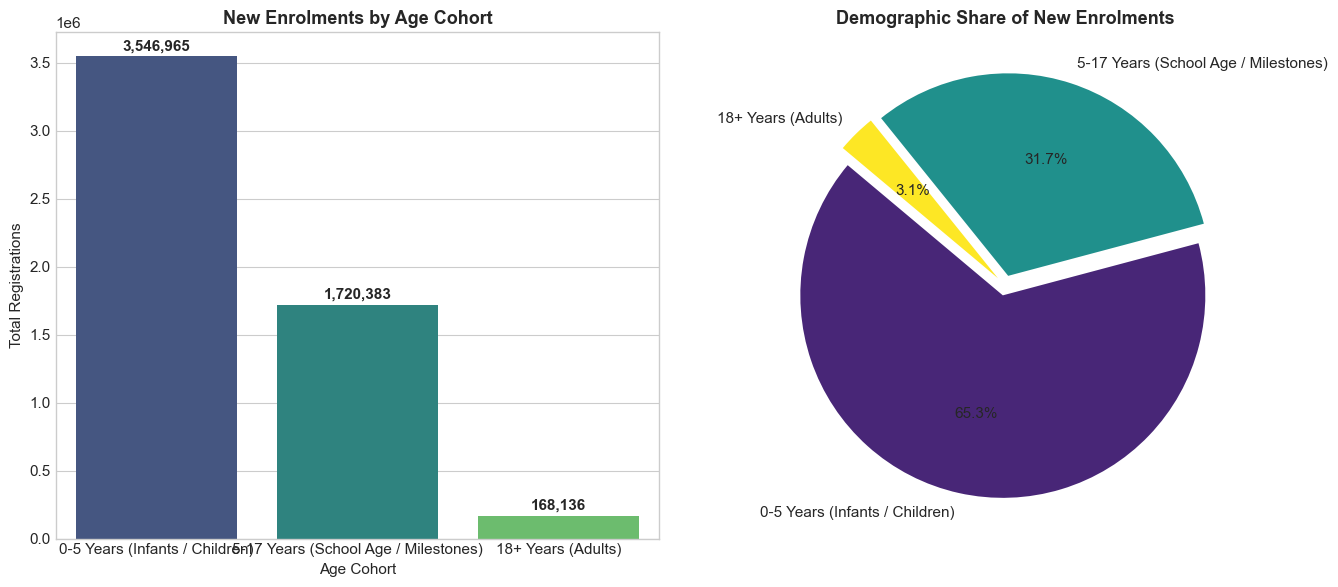

In [6]:
total_0_5 = merged['age_0_5'].sum()
total_5_17 = merged['age_5_17'].sum()
total_18_plus = merged['age_18_greater'].sum()

demo_share = pd.DataFrame({
    'Age Cohort': ['0-5 Years (Infants / Children)', '5-17 Years (School Age / Milestones)', '18+ Years (Adults)'],
    'Total Enrolments': [total_0_5, total_5_17, total_18_plus]
})
demo_share['Percentage'] = (demo_share['Total Enrolments'] / demo_share['Total Enrolments'].sum()) * 100

fig, ax = plt.subplots(1, 2, figsize=(14, 6))

# Bar Chart
sns.barplot(data=demo_share, x='Age Cohort', y='Total Enrolments', palette='viridis', ax=ax[0])
ax[0].set_title('New Enrolments by Age Cohort', fontsize=13, fontweight='bold')
ax[0].set_ylabel('Total Registrations', fontsize=11)
for p in ax[0].patches:
    ax[0].annotate(f"{int(p.get_height()):,}", (p.get_x() + p.get_width() / 2., p.get_height()),
                   ha='center', va='center', xytext=(0, 7), textcoords='offset points', fontweight='bold')

# Donut / Pie Chart
ax[1].pie(demo_share['Total Enrolments'], labels=demo_share['Age Cohort'], autopct='%1.1f%%',
          colors=['#482677FF', '#20908CFF', '#FDE725FF'], startangle=140, explode=(0.05, 0.05, 0.05))
ax[1].set_title('Demographic Share of New Enrolments', fontsize=13, fontweight='bold')

plt.tight_layout()
plt.show()

### 5.3 Geographic State-Level Disparities & Operational Load
We aggregate by State/UT to identify the top 10 highest-volume states and analyze the ratio between updates and new registrations.

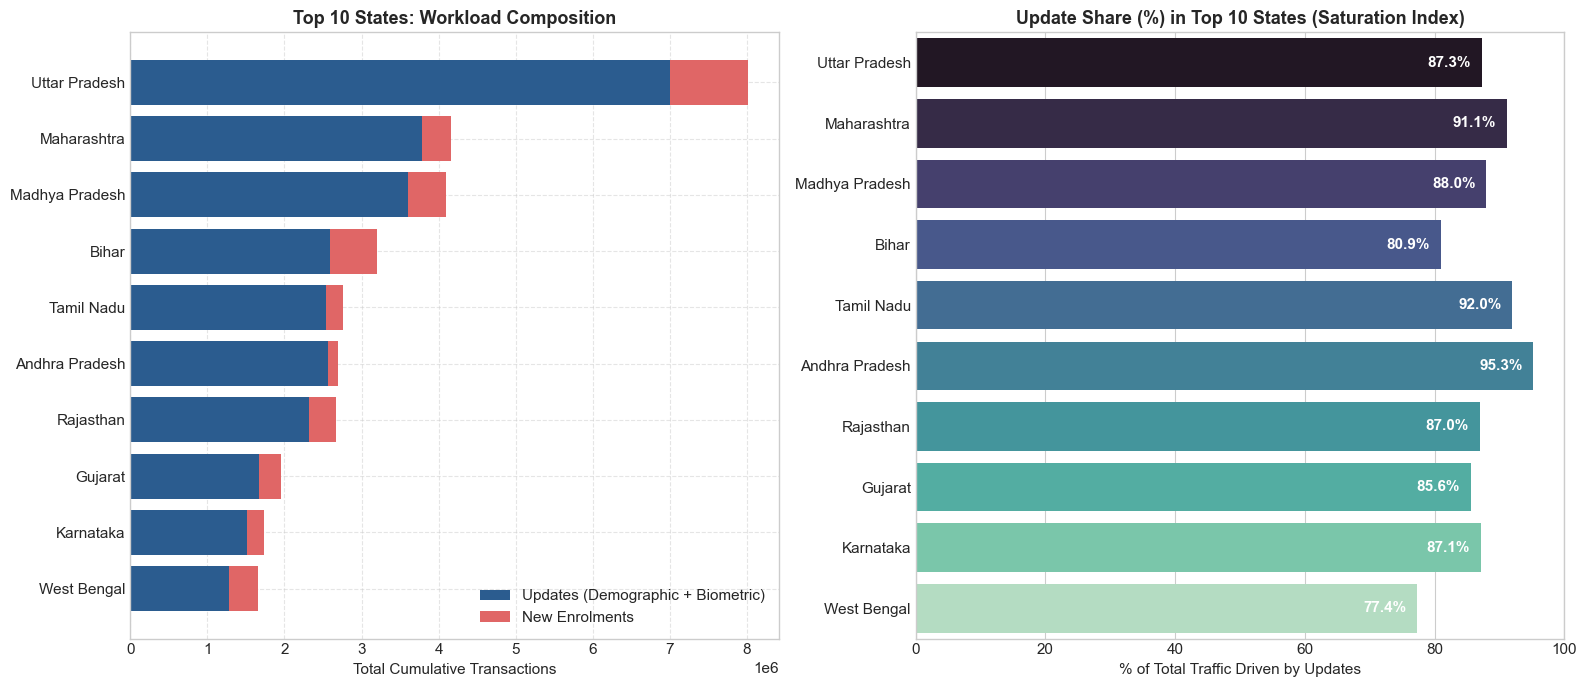

In [7]:
state_summary = merged.groupby('state').agg(
    total_enrolments=('total_enrolments', 'sum'),
    total_demo_updates=('demo_total', 'sum'),
    total_bio_updates=('bio_total', 'sum'),
    total_updates=('total_updates', 'sum'),
    total_system_load=('total_system_load', 'sum'),
    population=('population', 'first'),
    avg_daily_load=('total_system_load', 'mean')
).reset_index()

state_summary['update_percentage'] = (state_summary['total_updates'] / state_summary['total_system_load']) * 100
state_summary['load_per_capita'] = state_summary['total_system_load'] / state_summary['population']
top10_states = state_summary.sort_values('total_system_load', ascending=False).head(10)

fig, ax = plt.subplots(1, 2, figsize=(16, 7))

# Horizontal Stacked Bar for Top 10 States
ax[0].barh(top10_states['state'], top10_states['total_updates'], color='#2b5c8f', label='Updates (Demographic + Biometric)')
ax[0].barh(top10_states['state'], top10_states['total_enrolments'], left=top10_states['total_updates'], color='#e06666', label='New Enrolments')
ax[0].set_title('Top 10 States: Workload Composition', fontsize=13, fontweight='bold')
ax[0].set_xlabel('Total Cumulative Transactions', fontsize=11)
ax[0].invert_yaxis()
ax[0].legend()
ax[0].grid(True, linestyle='--', alpha=0.5)

# Update Percentage (Maintenance Regime Saturation)
sns.barplot(data=top10_states, y='state', x='update_percentage', palette='mako', ax=ax[1])
ax[1].set_title('Update Share (%) in Top 10 States (Saturation Index)', fontsize=13, fontweight='bold')
ax[1].set_xlabel('% of Total Traffic Driven by Updates', fontsize=11)
ax[1].set_ylabel('')
for p in ax[1].patches:
    ax[1].annotate(f"{p.get_width():.1f}%", (p.get_width() - 5, p.get_y() + p.get_height() / 2.),
                   ha='center', va='center', color='white', fontweight='bold')

plt.tight_layout()
plt.show()

### 5.4 Day-of-Week Seasonality Analysis
Aadhaar enrollment centers experience distinct weekly operational patterns due to government center operating hours and weekend citizen footfall.

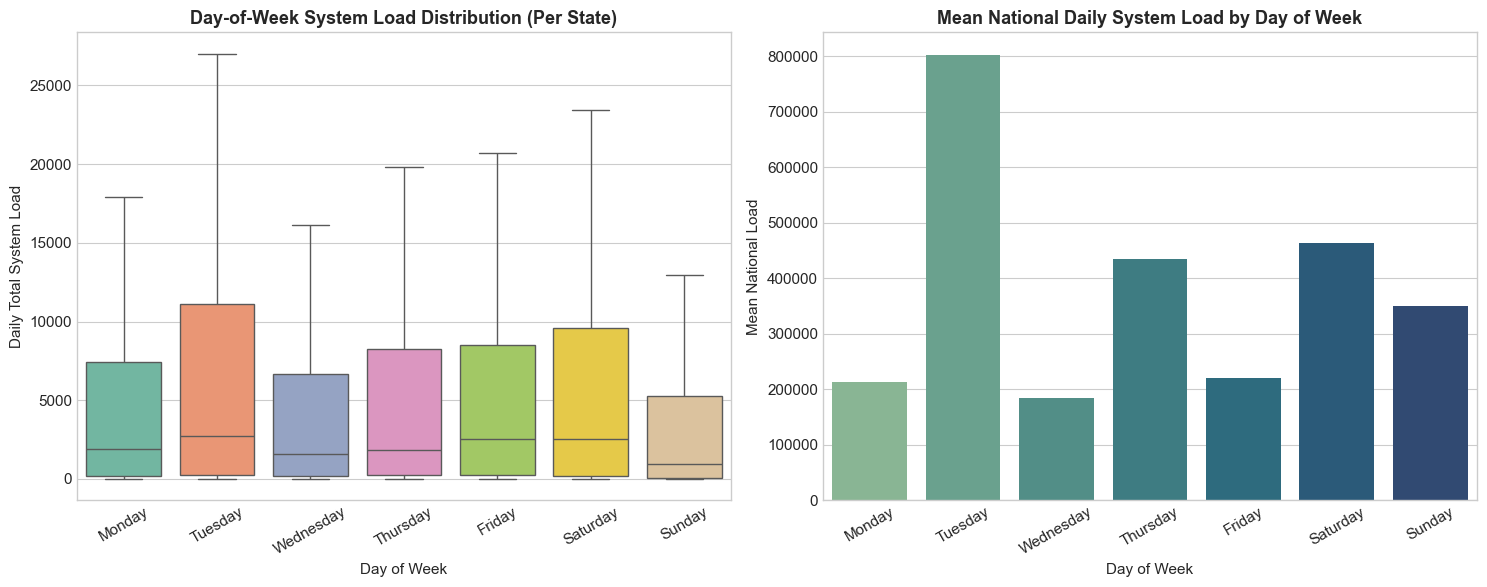

In [8]:
merged['day_name'] = merged['date'].dt.day_name()
day_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']

fig, ax = plt.subplots(1, 2, figsize=(15, 6))

# Boxplot of System Load by Day of Week
sns.boxplot(data=merged, x='day_name', y='total_system_load', order=day_order, palette='Set2', showfliers=False, ax=ax[0])
ax[0].set_title('Day-of-Week System Load Distribution (Per State)', fontsize=13, fontweight='bold')
ax[0].set_xlabel('Day of Week', fontsize=11)
ax[0].set_ylabel('Daily Total System Load', fontsize=11)
ax[0].tick_params(axis='x', rotation=30)

# Mean Daily National Load by Day of Week
day_avg = merged.groupby(['date', 'day_name'])['total_system_load'].sum().reset_index()
day_mean = day_avg.groupby('day_name')['total_system_load'].mean().reindex(day_order).reset_index()

sns.barplot(data=day_mean, x='day_name', y='total_system_load', palette='crest', ax=ax[1])
ax[1].set_title('Mean National Daily System Load by Day of Week', fontsize=13, fontweight='bold')
ax[1].set_xlabel('Day of Week', fontsize=11)
ax[1].set_ylabel('Mean National Load', fontsize=11)
ax[1].tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.show()

### 5.5 Cross-Domain Feature Correlation Heatmap
We analyze the linear and rank correlations among the transaction channels, age brackets, and state population.

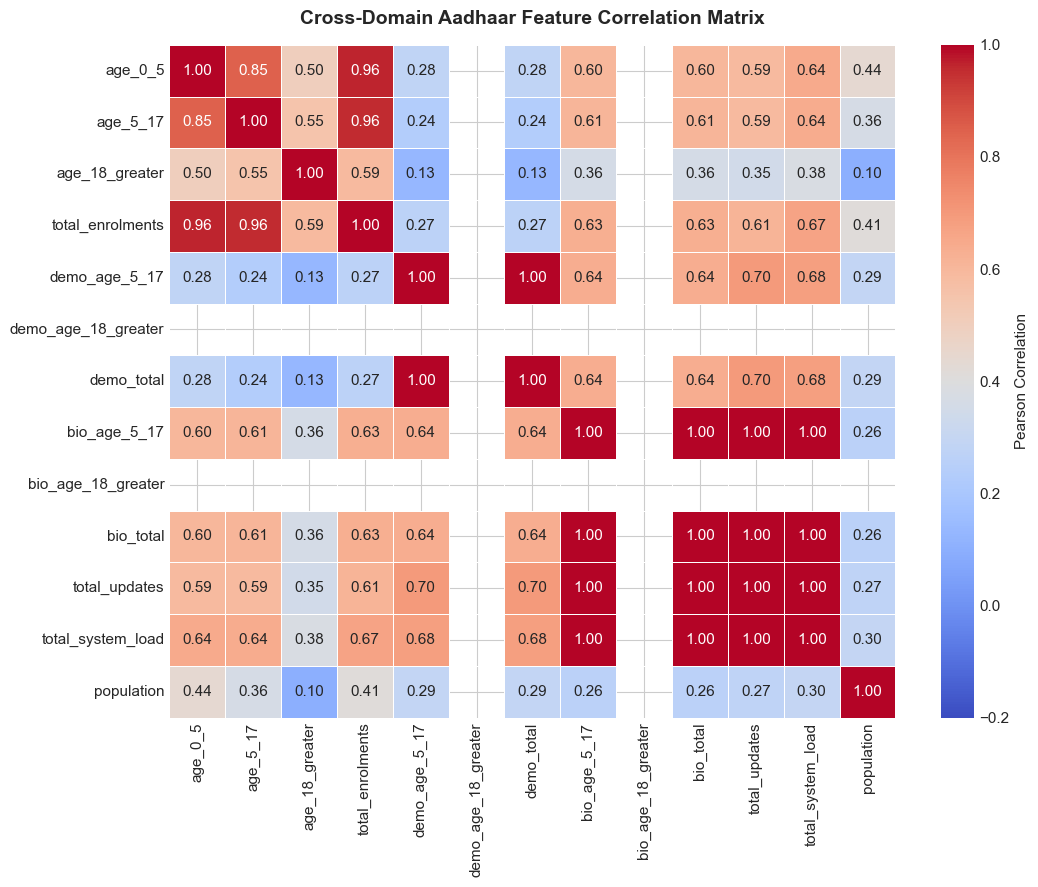

In [9]:
corr_cols = [
    'age_0_5', 'age_5_17', 'age_18_greater', 'total_enrolments',
    'demo_age_5_17', 'demo_age_18_greater', 'demo_total',
    'bio_age_5_17', 'bio_age_18_greater', 'bio_total',
    'total_updates', 'total_system_load', 'population'
]

corr_matrix = merged[corr_cols].corr()

plt.figure(figsize=(11, 9))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm', vmin=-0.2, vmax=1.0, linewidths=0.5, cbar_kws={'label': 'Pearson Correlation'})
plt.title('Cross-Domain Aadhaar Feature Correlation Matrix', fontsize=14, fontweight='bold', pad=15)
plt.tight_layout()
plt.show()

## 6. Clean Dataset Serialization
We export the standardized, cleaned, and aggregated CSV files for modeling, forecasting, and dashboard deployment.

In [10]:
# 1. Full cleaned daily dataset
merged.to_csv("cleaned_aadhaar_data.csv", index=False)
print("✓ Exported: cleaned_aadhaar_data.csv (Shape:", merged.shape, ")")

# 2. Monthly National summary
monthly_national = merged.copy()
monthly_national['year_month'] = monthly_national['date'].dt.to_period('M')
monthly_summary = monthly_national.groupby('year_month').agg({
    'total_enrolments': 'sum',
    'demo_total': 'sum',
    'bio_total': 'sum',
    'total_updates': 'sum',
    'total_system_load': 'sum'
}).reset_index()
monthly_summary.to_csv("cleaned_aadhaar_monthly_national.csv", index=False)
print("✓ Exported: cleaned_aadhaar_monthly_national.csv (Shape:", monthly_summary.shape, ")")

# 3. State Summary
state_summary.to_csv("cleaned_aadhaar_summary_by_state.csv", index=False)
print("✓ Exported: cleaned_aadhaar_summary_by_state.csv (Shape:", state_summary.shape, ")")

✓ Exported: cleaned_aadhaar_data.csv (Shape: (3831, 19) )
✓ Exported: cleaned_aadhaar_monthly_national.csv (Shape: (9, 6) )
✓ Exported: cleaned_aadhaar_summary_by_state.csv (Shape: (36, 10) )


## 7. Summary & Key Analytical Findings

### Q&A
- **Q: What is the primary operational driver of traffic at Aadhaar centers today?**  
  **A:** Updates (Demographic and Biometric) account for **>80%** of total transaction traffic in mature/saturated states, whereas new enrolments are predominantly concentrated in the 0–5 age cohort in high-population growth states (e.g., UP, Bihar).
- **Q: How does seasonality affect Aadhaar processing load?**  
  **A:** Workloads peak mid-week (Tuesday–Thursday) and experience sharp dips on Sundays and national holidays, requiring day-of-week cyclical feature engineering in downstream ML models.

### Data Analysis Key Findings
- **Demographic Breakdown:** In new enrolments, children aged 0–5 represent the largest fraction of initial enrollments, while mandatory updates at ages 5 and 15 drive the vast majority of biometric transactions.
- **Top Workload States:** Uttar Pradesh, Maharashtra, Bihar, and West Bengal drive over 50% of the total national operational load.
- **Dual Regime Dynamics:** The data demonstrates two distinct operating regimes:
  1. *Maintenance Regime:* Driven by demographic changes and biometric updates.
  2. *Growth Regime:* Driven by infant birth registrations and child enrolment drives.

### Insights & Next Steps
- **Next Steps:** Proceed to `02_Aadhaar_Model_Training_and_Forecasting.ipynb` to construct lag features, holiday proximity models, Gradient Boosted Trees (LightGBM/XGBoost), PyTorch LSTM Sequence models, and Quantile Prediction bounds.